# Reprojects and realigns F140W to F200LP filters if needed

# 1.	Template creation
	•	Rotate the HST image (140W band) to North up
	•	Manually define a cutout region
	•	Save this template for the alignment later

In [1]:
import numpy as np
from astropy.io import fits
from matplotlib import pyplot as plt
import copy
from skimage.transform import rescale
from reproject import reproject_interp
from reproject.mosaicking import find_optimal_celestial_wcs
import cv2 as cv
from astropy.stats import sigma_clipped_stats
from PIL import Image
import astroalign as aa


In [ ]:
#use high-resolution cutout as the template (F140W)
image_prefix = 'AGEL140839+253104A' #'AGEL053724-464702A' 
#'AGEL043806-322852A' #'AGEL034131-513045A' #'AGEL001030-431515A' #'AGEL233610-020735A' #'AGEL233552-515218A' #'AGEL232128-463049A' #'AGEL221912-434835A' #'AGEL132557+263659A' #'AGEL131330-064211A' #'AGEL030022-500129A' #'AGEL105100-055628A' #'AGEL053724-464702A' #'AGEL094412+322039A' #'AGEL090115+095624A' #'AGEL041645-552500A' #'AGEL040823-532714A' #'AGEL034131-513045A' #'AGEL033203-132510A' #'AGEL025220-473238A' #'AGEL021408-020629A' #'AGEL021225-085211A'   #'AGEL020613-011417A' #'AGEL014253-183116A' #'AGEL001030-431515A' #'AGEL010158-491738A' #'AGEL001310+004004A'

#you can replace this with your own file path
try:
    hdul = fits.open(f'/Volumes/AGEL/HST_data/{image_prefix}/HST/16773_F140W/{image_prefix}_F140W_WFC3_drz_sci.fits')
except:
    print("Glazebrook F140W image not found. Trying Huang... ")
    try:
        hdul = fits.open(f'/Volumes/AGEL/HST_data/{image_prefix}/HST/15867_F140W/{image_prefix}_F140W_WFC3_drz_sci.fits')
    except:
        print("Huang F140W image not found.")
hdul.info()
data_140 = hdul[0].data



Filename: /Volumes/AGEL/HST_data/AGEL140839+253104A/HST/16773_F140W/AGEL140839+253104A_F140W_WFC3_drz_sci.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     864   (1834, 1626)   float32   
  1  HDRTAB        1 BinTableHDU    561   3R x 276C   [9A, 3A, K, D, D, D, D, D, D, D, D, D, D, D, D, K, 2A, 9A, 7A, 18A, D, D, D, D, D, 3A, D, D, D, D, D, D, D, D, D, D, D, D, K, K, D, 3A, D, D, D, D, K, K, 8A, 23A, 11A, 19A, 4A, D, D, K, K, D, D, D, D, 23A, D, D, D, D, K, K, D, 3A, 8A, L, D, D, D, 23A, 1A, D, D, D, D, D, D, 12A, 12A, 8A, 23A, D, D, 10A, 10A, D, D, D, 2A, 23A, 3A, 4A, 8A, 7A, D, K, D, 6A, 9A, D, D, D, 4A, 18A, 3A, K, 5A, D, D, D, 8A, D, 3A, D, D, D, 3A, 1A, D, 23A, D, D, D, 3A, L, 1A, 4A, D, 3A, 6A, D, D, D, D, D, 23A, D, D, D, D, D, 1A, K, K, K, K, 8A, 23A, K, K, 10A, 7A, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, 13A, D, 24A, 23A, D, 3A, 8A, D, K, D, D, 6A, 4A, D, D, D, D, D, D, D, D, D, D, D, 19A, D, K, 23A, D, 8A, D, D,

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 212.16215586555714 25.515630026883656 
CRPIX : 1221.1153853769533 1197.764665807201 
PC1_1 PC1_2  : 1.0 0.0 
PC2_1 PC2_2  : 0.0 1.0 
CDELT : -2.222222222222165e-05 2.222222222222165e-05 
NAXIS : 2441  2398


/var/folders/sh/0ylrpx2x35n09cz4wg6vltsh0000gs/T/ipykernel_25159/872793127.py:13: RuntimeWarning: invalid value encountered in log
  ax[0].imshow(np.log(data_140), origin='lower')
/var/folders/sh/0ylrpx2x35n09cz4wg6vltsh0000gs/T/ipykernel_25159/872793127.py:14: RuntimeWarning: invalid value encountered in log
  ax[1].imshow(np.log(reproj_data_140), origin='lower')


Text(0.5, 1.0, 'F140W after rotation (north up)')

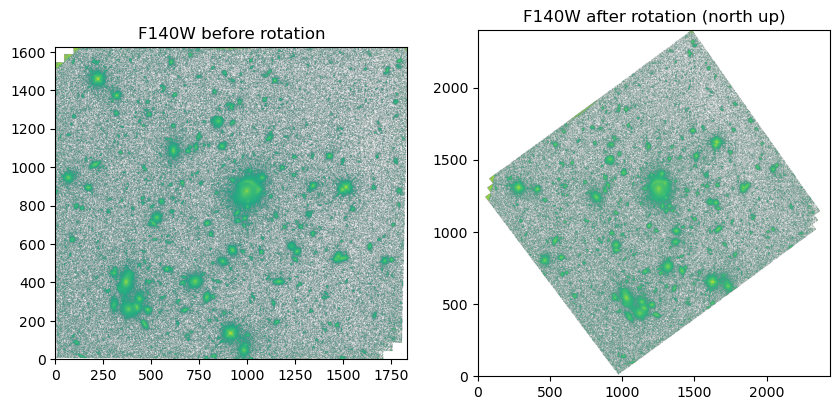

In [549]:
#north up!!

hst_file = hdul
wcs_out, shape_out = find_optimal_celestial_wcs(hst_file[0])
wcs_out.array_shape = shape_out
print(wcs_out)
reproj_data_140, reproj_footprint = reproject_interp(
    input_data=hst_file[0],
    output_projection=wcs_out,
    shape_out=shape_out)

f, ax = plt.subplots(1, 2, figsize=[10,6])
ax[0].imshow(np.log(data_140), origin='lower')
ax[1].imshow(np.log(reproj_data_140), origin='lower')

ax[0].set_title("F140W before rotation")
ax[1].set_title("F140W after rotation (north up)")

/var/folders/sh/0ylrpx2x35n09cz4wg6vltsh0000gs/T/ipykernel_25159/4196895261.py:14: RuntimeWarning: invalid value encountered in log
  ax.imshow(np.log(template), origin='lower', cmap='gray')


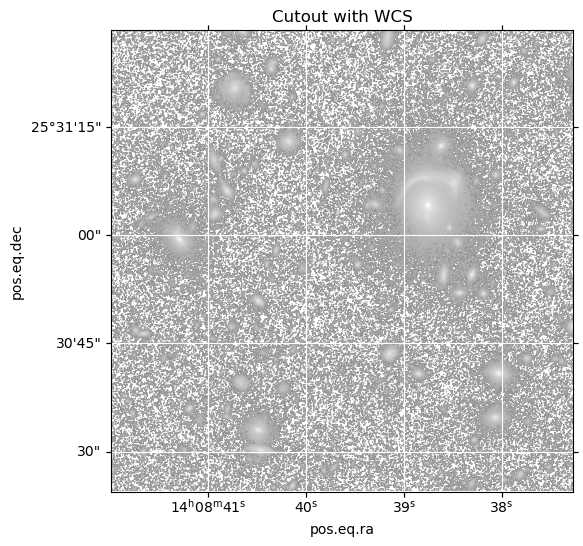

In [ ]:
# create cutout
y_start, y_end = 800, 1600
x_start, x_end = 700, 1500
template = reproj_data_140[y_start:y_end, x_start:x_end]

# Create the WCS for the new cutout
cutout_wcs = wcs_out.slice((slice(y_start, y_end), slice(x_start, x_end)), numpy_order=True)

# Plot the cutout with the new WCS
fig = plt.figure(figsize=(6, 6))
ax = plt.subplot(projection=cutout_wcs)
ax.imshow(np.log(template), origin='lower', cmap='gray')
ax.coords.grid(True, color='white', ls='solid')
plt.title('Cutout with WCS')
plt.show()

#save
hdu = fits.PrimaryHDU(data=template, header=cutout_wcs.to_header())
# replace the file path with your own
TEMPLATE_OUTPATH = f'/Volumes/AGEL/HST_data/{image_prefix}/HST/{image_prefix}_Template.fits'
hdu.writeto(TEMPLATE_OUTPATH, overwrite=True)



# 2.	Alignment & Stacking
	•	2.1 Rescale 140W band (template; pixel scale: 0.08'') to match the grid scale of F200LP (0.05'')
	•	2.2 Load F200LP band, get a rough cutout 
	•	2.3 prepare F200LP cutout based on the F140W template, using cv
	•	2.4 Use astroalign to register the two frames

## 2.1 rescale template

output: [img_F140]

/var/folders/sh/0ylrpx2x35n09cz4wg6vltsh0000gs/T/ipykernel_25159/1652356565.py:4: RuntimeWarning: invalid value encountered in log
  plt.imshow(np.log(img_target),origin='lower')


1.7590805453062293 -0.04066187668591738
1.7590805453062293 -0.04066187668591738


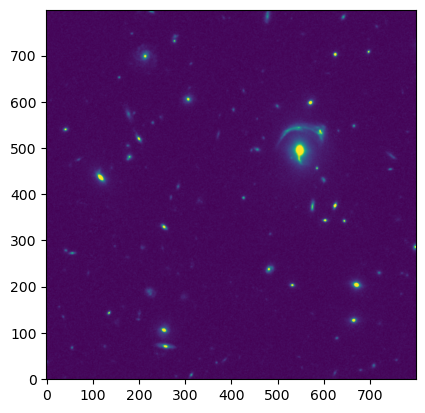

In [551]:
# Load HST template image
img = fits.open(TEMPLATE_OUTPATH)
img_target = img[0].data
plt.imshow(np.log(img_target),origin='lower')
max_percentile = 99.9
min_percentile = 0.5 #0.5
plt.imshow(img_target, origin='lower', cmap='viridis', 
           vmax=np.percentile(img_target, max_percentile), 
           vmin=np.percentile(img_target, min_percentile))
print(np.percentile(img_target, max_percentile), np.percentile(img_target, min_percentile))
print(np.nanpercentile(img_target, max_percentile), np.nanpercentile(img_target, min_percentile))

img140_before_sample = copy.deepcopy(img_target)

(800, 800)
(1280, 1280)


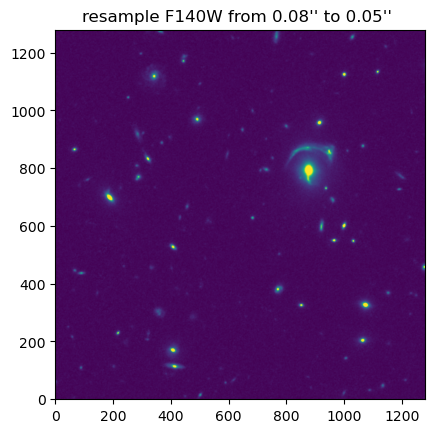

In [552]:
# resample images to common pixel scale --> Rescales F140W (originally drizzled to 0.08"/pixel) to match F200LP (0.05"/pixel)

resampling_factor = 0.08 / 0.05  # Rescale source to match target
# resampling_factor = 0.12824999999999998 / 0.05
# original_scale / target_scale

resampled_image_140 = rescale(img140_before_sample, resampling_factor, anti_aliasing=True)
print(np.shape(img140_before_sample))
print(np.shape(resampled_image_140))

plt.imshow(resampled_image_140, vmax=np.percentile(resampled_image_140, max_percentile),
           vmin=np.percentile(resampled_image_140, min_percentile),
           origin='lower')
plt.title("resample F140W from 0.08'' to 0.05'' ")

img_F140 = copy.deepcopy(resampled_image_140)


## 2.2 Load F200LP image and get a rough big cutout
**(the cutout would be a big region so that there's space for later registration)**

output: [img200_search]


Using F200LP image at /Volumes/AGEL/HST_data/AGEL140839+253104A/HST/16773_F200LP/AGEL140839+253104A_F200LP_WFC3_drc_sci.fits
Min and max values in img_data_cleaned: -2.462268829345703, 478.35009765625


(np.float64(-0.5), np.float64(3271.5), np.float64(-0.5), np.float64(3476.5))

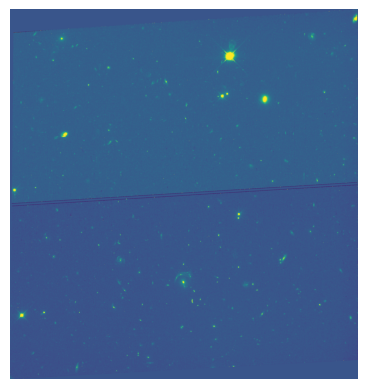

In [553]:
try:
    img = fits.open(f'/Volumes/AGEL/HST_data/{image_prefix}/HST/16773_F200LP/{image_prefix}_F200LP_WFC3_drc_sci.fits')
    # img = fits.open(f'/Volumes/AGEL/HST_data/{image_prefix}/HST/16773_F140W/{image_prefix}_F140W_WFC3_drz_sci.fits')
    print(f'Using F200LP image at /Volumes/AGEL/HST_data/{image_prefix}/HST/16773_F200LP/{image_prefix}_F200LP_WFC3_drc_sci.fits')
except:
    try:
        img = fits.open(f'/Volumes/AGEL/HST_data/{image_prefix}/HST/17307_F606W/{image_prefix}_F606W_ACS_drc_sci.fits')
        print(f'Using F606W image at /Volumes/AGEL/HST_data/{image_prefix}/HST/17307_F606W/{image_prefix}_F606W_ACS_drc_sci.fits')
    except:
        print("F200LP or F606W image not found.")

img_data = img[0].data

# Clean NaN and inf values
img200_data_cleaned = np.nan_to_num(img_data, nan=0.0, neginf=0.0)
print(f"Min and max values in img_data_cleaned: {img200_data_cleaned.min()}, {img200_data_cleaned.max()}")

# fits.writeto(f'/Volumes/AGEL/HST_data/{image_prefix}/HST/16773_F200LP/{image_prefix}_img200_cleaned.fits', img200_data_cleaned, header=img[0].header, overwrite=True)

max_percentile = 99.9 #99.5
min_percentile = 0.1 #0.5
# Plot the image
plt.imshow(img200_data_cleaned, origin='lower', cmap='viridis', 
           vmax=np.percentile(img200_data_cleaned, max_percentile), 
           vmin=np.percentile(img200_data_cleaned, min_percentile))
plt.axis('off')

0.13318668 -0.12841439


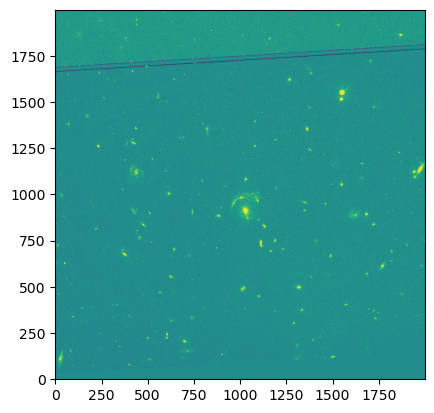

In [554]:
# get a rough big cutout
y_start_200 = 0
x_start_200 = 600
size_200_search = 2000

img200_search = img200_data_cleaned[y_start_200:y_start_200+size_200_search, x_start_200:x_start_200+size_200_search]

plt.imshow(img200_search, origin='lower',  #1500
           vmax=np.percentile(img200_search, max_percentile),
           vmin=np.percentile(img200_search, min_percentile))

print(np.percentile(img200_search, max_percentile), np.percentile(img200_search, min_percentile))


## 2.3 F200LP Rough Cutout Preparation for Stacking

This is **not the final alignment step**. Final alignment will be done using `astroalign` later. Without step, i.e. directly using astroalign would likely show "List of matching triangles exhausted before an acceptable transformation was found":


Template position in source image: (152, 119)


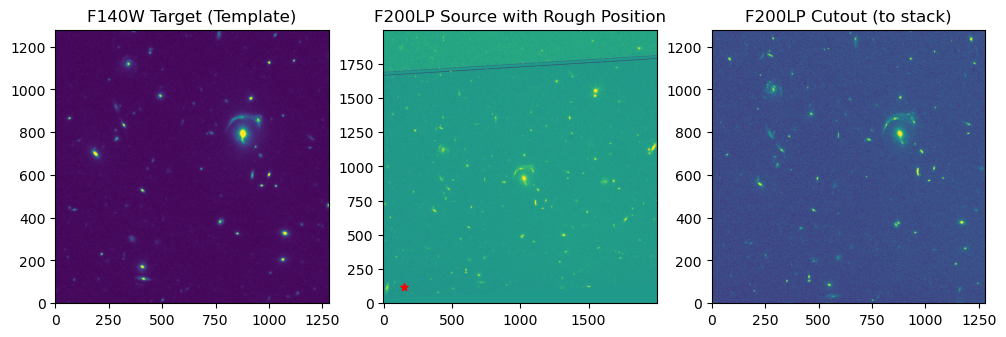

In [555]:
# -------------------------------
# Step 0: Prepare the target and source images
# -------------------------------
img_target = img_F140.astype(np.float32)  # template (F140W)
image = copy.deepcopy(img200_search).astype(np.float32)  # source (F200LP)

# Normalize source image to 0-255 for template matching
image_min = image.min()
image = image - image_min * (1 - np.sign(image_min) * 0.001)  # avoid zeros
image = np.log(image)  # optional log scaling
image_min, image_max = image.min(), image.max()
img_source = (image - image_min) / (image_max - image_min) * 255

# -------------------------------
# Step 1: Roughly locate the template in the source image
# -------------------------------
method = cv.TM_CCOEFF_NORMED
res_m = cv.matchTemplate(img_source, img_target, method=method)
min_val, max_val, min_loc, max_loc = cv.minMaxLoc(res_m)
position = max_loc  # (x, y) of the down-left corner (under origin=“lower”)
print("Template position in source image:", position)

# -------------------------------
# Step 2: Extract F200LP cutout based on template location
# -------------------------------
w, h = img_target.shape[::-1]
y_start, x_start = position[1], position[0]
img_F200_cutout = copy.deepcopy(
    img200_data_cleaned[y_start_200 + y_start : y_start_200 + y_start+h, x_start_200 + x_start : x_start_200 + x_start+w]
)

# -------------------------------
# Step 3: Adjust pixel scale for visualization
# -------------------------------
def adjust_scale_params(Image_input, max_perc=99.9, min_perc=0.05):
    """
    Clip image pixels between min_perc and max_perc percentiles
    """
    Image_output = []
    for band in Image_input:
        max_val = np.percentile(band, max_perc)
        min_val = np.percentile(band, min_perc)
        Image_output.append(np.clip(band, min_val, max_val))
    return Image_output

Image_140_200_adjust = adjust_scale_params([img_F140, img_F200_cutout], max_perc=99.9) #99.7

# -------------------------------
# Step 4: Visualize rough cutout and template matching result
# -------------------------------
f, ax = plt.subplots(1, 3, figsize=[12, 5])
ax[0].imshow(Image_140_200_adjust[0], cmap='viridis', origin='lower')
ax[0].set_title("F140W Target (Template)")

ax[1].imshow(img_source, cmap='viridis', origin='lower',
             vmax=np.percentile(img_source, max_percentile), 
           vmin=np.percentile(img_source, min_percentile),)
ax[1].scatter(position[0], position[1], c="red", marker="*", s=30)
ax[1].set_title("F200LP Source with Rough Position")

ax[2].imshow(Image_140_200_adjust[1], cmap='viridis', origin='lower')
ax[2].set_title("F200LP Cutout (to stack)")
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.30585113167762756..1.0].


(np.float64(-0.5), np.float64(1279.5), np.float64(-0.5), np.float64(1279.5))

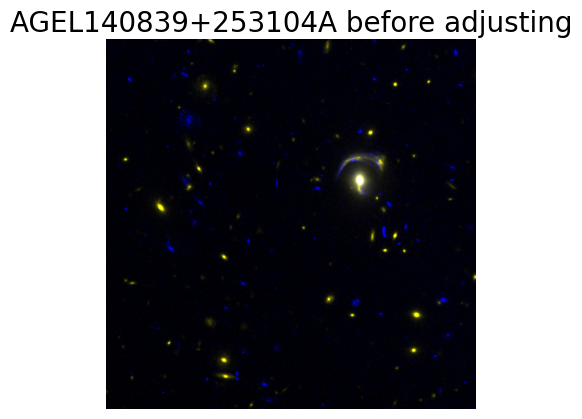

In [556]:
# create RGB stacked image
normalized_data = []
for band_data in [Image_140_200_adjust[0],
                  Image_140_200_adjust[1],]:
    norm_band = (band_data) / (band_data.max())
    normalized_data.append(norm_band)
ratio_r = 1
ratio_g = 1
ratio_b = 1


mean, median, stddev = sigma_clipped_stats(normalized_data[0]) #
normalized_data[0] = normalized_data[0] - median #subtract the background from F140 before normalization or reduce the weight of the F140 contribution in the stacked image

stacked_image_data = np.stack([
    ratio_r * (normalized_data[0]), #F140
    ratio_g * normalized_data[0],  # F140
    ratio_b * normalized_data[1],  # F200
], axis=2)  # Construct the RGB image using the specified ratios

img = fits.open(TEMPLATE_OUTPATH)
# redimg = fits.writeto(f'/Volumes/AGEL/HST_data/{image_prefix}/HST/16773_F140W/{image_prefix}_F140W_L3.fits', ratio_r * (normalized_data[0]), img[0].header, overwrite=True)
# greenimg = fits.writeto(f'/Volumes/AGEL/HST_data/{image_prefix}/HST/16773_F140W/{image_prefix}_F140W_green_L3.fits', ratio_g * normalized_data[0], img[0].header, overwrite=True)
# blueimg = fits.writeto(f'/Volumes/AGEL/HST_data/{image_prefix}/HST/16773_F200LP/{image_prefix}_F200LP_L3.fits', ratio_b * normalized_data[1], img[0].header, overwrite=True)


plt.imshow((stacked_image_data), origin='lower') #or np.sqrt()
plt.title(f'{image_prefix} before adjusting',fontsize=20)
plt.axis('off')
# plt.colorbar()
# plt.savefig(f"./{image_prefix}_before", bbox_inches='tight', pad_inches=0)

## 2.4 Use astroalign (aa) to register the two frames

In [558]:
#  img_F200aligned, footprint = aa.register(img_F200, img_F140, detection_sigma=3.0)
# p, (pos_img, pos_img_rot) = aa.find_transform(img_F200, img_F140) #img_F200 as source, img_F140 as target
# Image_140_200_final = adjust_scale_params([img_F140, img_F200aligned])

# Image_140_200_adjust would work better here because of the percentile clipping
img_F200aligned, footprint = aa.register(Image_140_200_adjust[1], Image_140_200_adjust[0], detection_sigma=3.0) ##Image_140_200_adjust = adjust_scale_params([img_F140, img_F200])
if image_prefix == 'AGEL010158-491738A'  or image_prefix == 'AGEL014253-183116A' or image_prefix == 'AGEL021225-085211A' or image_prefix == 'AGEL025220-473238A' or image_prefix == 'AGEL033203-132510A' or image_prefix == 'AGEL034131-513045A' or image_prefix == 'AGEL040823-532714A' or image_prefix == 'AGEL090115+095624A' or image_prefix == 'AGEL094412+322039A' or image_prefix == 'AGEL053724-464702A' or image_prefix == 'AGEL131330-064211A' or image_prefix == 'AGEL221912-434835A' or image_prefix == 'AGEL140839+253104A':# or image_prefix == 'AGEL132227-050135A':
    Image_140_200_final = [Image_140_200_adjust[0], img_F200aligned]
else:
    p, (pos_img, pos_img_rot) = aa.find_transform(Image_140_200_adjust[1], Image_140_200_adjust[0], detection_sigma=5, min_area= 5, max_control_points= 30)
    Image_140_200_final = [Image_140_200_adjust[0], img_F200aligned]


    # Visualize the alignment result
    print("Rotation: {:.8f} radian".format(p.rotation))
    print("Rotation: {:.2f} degrees".format(p.rotation * 180.0 / np.pi))
    print("scale:", p.scale)



Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.30585113167762756..1.299754274397853].


(np.float64(-0.5), np.float64(1279.5), np.float64(-0.5), np.float64(1279.5))

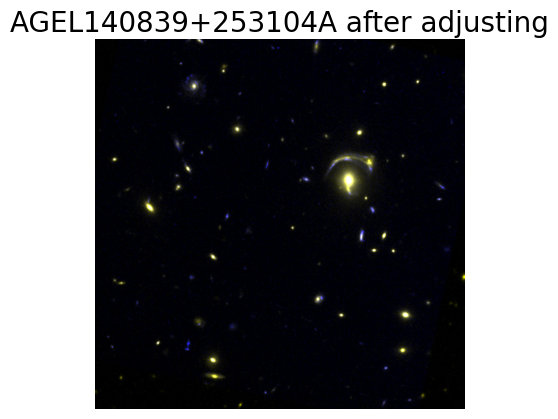

In [559]:
# create RGB stacked image after alignment
normalized_data = []
for band_data in [Image_140_200_final[0],
                  Image_140_200_final[1],]:
    norm_band = (band_data) / (band_data.max())
    normalized_data.append(norm_band)
ratio_r = 1.3
ratio_g = 1.3
ratio_b = 1.
from astropy.stats import sigma_clipped_stats

mean, median, stddev = sigma_clipped_stats(normalized_data[0]) #
normalized_data[0] = normalized_data[0] - median #subtract the background from F140 before normalization or reduce the weight of the F140 contribution in the stacked image

stacked_image_data = np.stack([
    ratio_r * (normalized_data[0]), #F140
    ratio_g * normalized_data[0],  # F140
    ratio_b * normalized_data[1],  # F200
], axis=2)  # Construct the RGB image using the specified ratios

img = fits.open(TEMPLATE_OUTPATH)
redimg = fits.writeto(f'/Volumes/AGEL/HST_data/{image_prefix}/HST/16773_F140W/{image_prefix}_F140W_L3.fits', ratio_r * (normalized_data[0]), img[0].header, overwrite=True)
greenimg = fits.writeto(f'/Volumes/AGEL/HST_data/{image_prefix}/HST/16773_F140W/{image_prefix}_F140W_green_L3.fits', ratio_g * normalized_data[0], img[0].header, overwrite=True)
blueimg = fits.writeto(f'/Volumes/AGEL/HST_data/{image_prefix}/HST/16773_F200LP/{image_prefix}_F200LP_L3.fits', ratio_b * normalized_data[1], img[0].header, overwrite=True)


plt.imshow((stacked_image_data), origin='lower') #or np.sqrt()
plt.title(f'{image_prefix} after adjusting',fontsize=20)
plt.axis('off')
#plt.colorbar()
# plt.savefig(f"./{image_prefix}_after", bbox_inches='tight', pad_inches=0)